# Projet — ETL Fruits & Légumes

**Objectif** : Préparer les données pour prédire le prix par cup d'un fruit ou légume.

**Source** : USDA ERS — Fruit and Vegetable Prices (2013, 2016, 2020, 2022, 2023)

**Variable cible** : `prix_cup` — prix réel d'une portion en dollars (régression)

---
Auteur : Certification DevIA Simplon RNCP 2026

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Couleurs pour les graphiques
ROUGE = '#C0392B'
BLEU  = '#3498DB'
VERT  = '#2ECC71'

print('OK')

OK


## 1. Chargement

Le fichier `ers_toutes_annees.csv` a été compilé depuis les archives USDA ERS.
Il contient les prix moyens de 132 fruits et légumes sur 5 années.

| Colonne | Description |
|---|---|
| `produit` | Nom du fruit ou légume |
| `forme` | Fresh / Canned / Frozen / Juice / Dried |
| `prix_detail` | Prix en supermarché (\$/lb) |
| `rendement` | Part utilisable après préparation (0 à 1) |
| `taille_cup` | Poids d'une portion standard |
| `prix_cup` | **Variable cible** — coût réel d'une portion (\$/cup) |
| `categorie` | fruit ou legume |
| `annee` | Année de collecte |

In [2]:
# Chargement du fichier CSV
# sep=';' car le fichier utilise le point-virgule comme séparateur
df = pd.read_csv('../DATA/ers_toutes_annees.csv', sep=';', encoding='utf-8') #.. pour revenir au niveau du dossier principal

print(f'Lignes   : {df.shape[0]}')
print(f'Colonnes : {df.shape[1]}')
print(f'Annees   : {sorted(df["annee"].unique())}')
print(f'Produits : {df["produit"].nunique()}')
df.head(5)

Lignes   : 704
Colonnes : 8
Annees   : [2013, 2016, 2020, 2022, 2023]
Produits : 150


,produit,forme,prix_detail,rendement,taille_cup,prix_cup,categorie,annee
0,Watermelon,Fresh,0.3334,0.520000,0.330693,0.2120,fruit,2013
1,Turnip greens,Frozen,1.4730,0.776027,0.352740,0.6696,legume,2013
2,Turnip greens,Fresh,2.4717,0.750000,0.319670,1.0535,legume,2013
3,Turnip greens,Canned,0.9653,0.650000,0.352740,0.5238,legume,2013
4,Tomatoes,Canned,0.9248,1.000000,0.540133,0.4995,legume,2013


## 2. Exploration

In [3]:
# Statistiques descriptives pour comprendre la distribution des données
df.describe()

,prix_detail,rendement,taille_cup,prix_cup,annee
count,704.000000,704.000000,704.000000,704.000000,704.000000
mean,2.313584,0.949576,0.953287,0.865506,2019.230114
std,1.702144,0.474718,2.074511,0.553962,3.731897
min,0.316600,0.375000,0.123163,0.174500,2013.000000
25%,1.179475,0.650000,0.319670,0.513800,2016.000000
50%,1.724750,0.910000,0.358251,0.708650,2020.000000
75%,2.810200,1.000000,0.385809,1.084125,2022.000000
max,10.552700,4.000000,8.000000,4.279216,2023.000000


In [4]:
# Vérification des valeurs manquantes
# Un bon dataset ne doit pas avoir de NaN dans les colonnes importantes
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

# Répartition des données par année et catégorie
print('\nNombre de lignes par annee et categorie :')
print(df.groupby(['annee', 'categorie']).size().unstack(fill_value=0))

Valeurs manquantes par colonne :
produit        0
forme          0
prix_detail    0
rendement      0
taille_cup     0
prix_cup       0
categorie      0
annee          0
dtype: int64

Nombre de lignes par annee et categorie :
categorie  fruit  legume
annee                   
2013          52      73
2016          51      72
2020          51      70
2022          78     102
2023          62      93


## 3. Nettoyage

Le dataset est déjà propre (pas de valeurs manquantes, pas de doublons).
On applique deux traitements :
1. Suppression des espaces parasites dans les colonnes texte
2. Encodage numérique des colonnes texte pour le modèle ML
   (un modèle ML ne peut pas lire "Fresh", il faut le convertir en chiffre)

In [5]:
# Suppression des espaces au début et à la fin des chaînes de caractères
df['produit']   = df['produit'].str.strip()
df['forme']     = df['forme'].str.strip()
df['categorie'] = df['categorie'].str.strip()

# Encodage de la forme en valeur numérique
# Le modèle ML a besoin de nombres, pas de mots
df['forme_encoded'] = df['forme'].map(
    {'Fresh': 0, 'Canned': 1, 'Frozen': 2, 'Juice': 3, 'Dried': 4}
)

# Encodage de la catégorie : fruit=1, legume=0
df['categorie_encoded'] = (df['categorie'] == 'fruit').astype(int)

print('Colonnes après nettoyage :')
print(df.dtypes)

Colonnes après nettoyage :
produit               object
forme                 object
prix_detail          float64
rendement            float64
taille_cup           float64
prix_cup             float64
categorie             object
annee                  int64
forme_encoded          int64
categorie_encoded      int32
dtype: object


## 4. Variable cible

La variable cible est **`prix_cup`** — le prix réel d'une portion standard en dollars.

C'est une valeur **continue** → on fait une **régression** (pas une classification).

Le modèle devra apprendre à prédire ce prix à partir des autres colonnes.

In [6]:
# Statistiques de la variable cible
print('Variable cible : prix_cup ($/cup)')
print(f'  Minimum  : {df["prix_cup"].min():.2f}$')
print(f'  Maximum  : {df["prix_cup"].max():.2f}$')
print(f'  Moyenne  : {df["prix_cup"].mean():.2f}$')
print(f'  Mediane  : {df["prix_cup"].median():.2f}$')
print(f'  Ecart-type : {df["prix_cup"].std():.2f}$')

Variable cible : prix_cup ($/cup)
  Minimum  : 0.17$
  Maximum  : 4.28$
  Moyenne  : 0.87$
  Mediane  : 0.71$
  Ecart-type : 0.55$


## 5. Visualisations

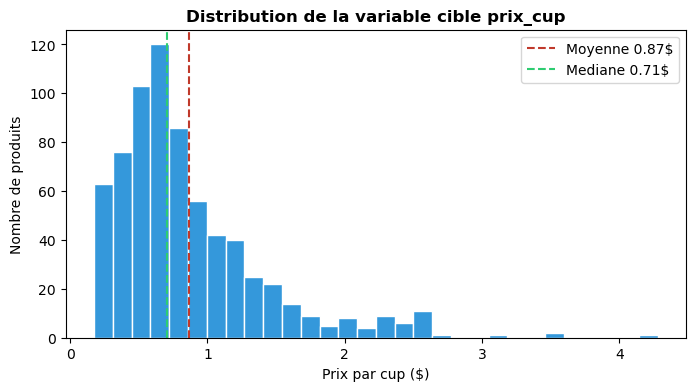

In [7]:
# Distribution de la variable cible prix_cup
# On s'attend à une distribution asymétrique (queue à droite)
plt.figure(figsize=(8, 4))
plt.hist(df['prix_cup'], bins=30, color=BLEU, edgecolor='white')
plt.axvline(df['prix_cup'].mean(),   color=ROUGE, linestyle='--',
            lw=1.5, label=f'Moyenne {df["prix_cup"].mean():.2f}$')
plt.axvline(df['prix_cup'].median(), color=VERT,  linestyle='--',
            lw=1.5, label=f'Mediane {df["prix_cup"].median():.2f}$')
plt.title('Distribution de la variable cible prix_cup', fontweight='bold')
plt.xlabel('Prix par cup ($)')
plt.ylabel('Nombre de produits')
plt.legend()
plt.show()

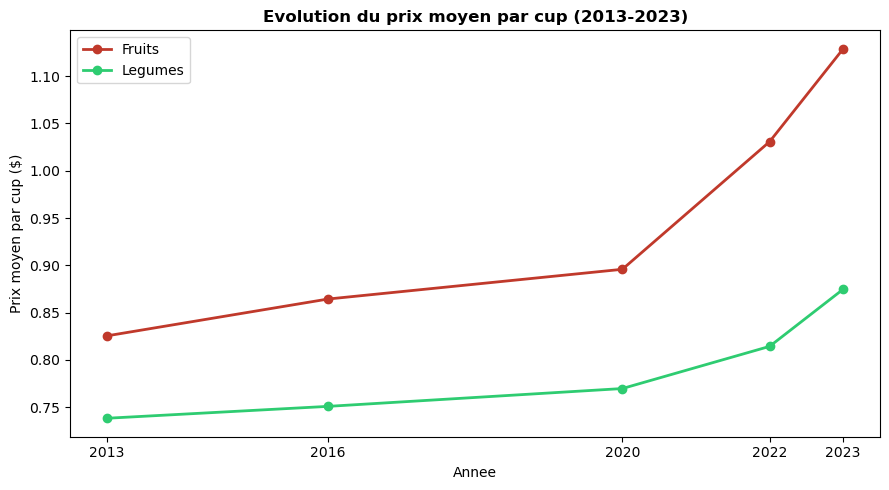

In [8]:
# Evolution du prix moyen par année
# Permet de voir si l'inflation alimentaire est visible dans les données
prix_annee = df.groupby(['annee', 'categorie'])['prix_cup'].mean().unstack()

plt.figure(figsize=(9, 5))
plt.plot(prix_annee.index, prix_annee['fruit'],
         color=ROUGE, marker='o', linewidth=2, label='Fruits')
plt.plot(prix_annee.index, prix_annee['legume'],
         color=VERT,  marker='o', linewidth=2, label='Legumes')
plt.title('Evolution du prix moyen par cup (2013-2023)', fontweight='bold')
plt.xlabel('Annee')
plt.ylabel('Prix moyen par cup ($)')
plt.legend()
plt.xticks(prix_annee.index)
plt.tight_layout()
plt.show()

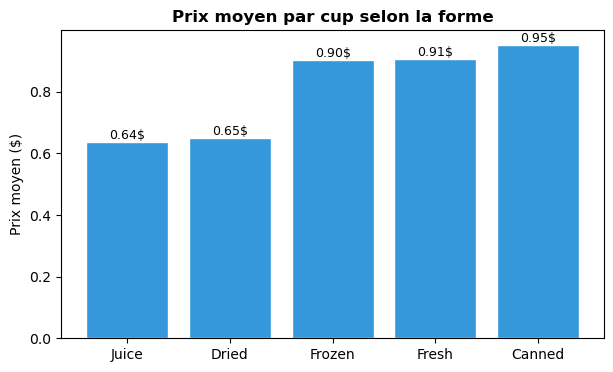

In [9]:
# Prix moyen par forme de produit
# Montre si la forme (frais, surgelé...) influence le prix
moy_forme = df.groupby('forme')['prix_cup'].mean().sort_values()

plt.figure(figsize=(7, 4))
plt.bar(moy_forme.index, moy_forme.values, color=BLEU, edgecolor='white')
plt.title('Prix moyen par cup selon la forme', fontweight='bold')
plt.ylabel('Prix moyen ($)')
for i, v in enumerate(moy_forme.values):
    plt.text(i, v + 0.01, f'{v:.2f}$', ha='center', fontsize=9)
plt.show()

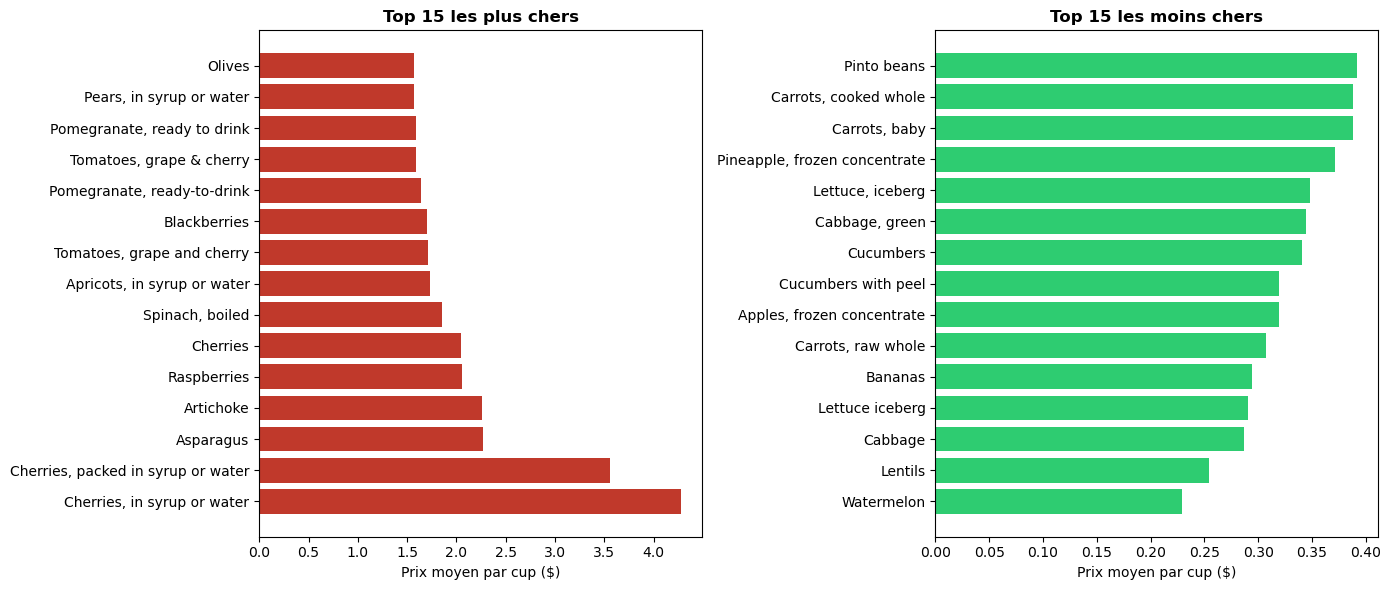

In [10]:
# Top 15 produits les plus chers et les moins chers
top  = df.groupby('produit')['prix_cup'].mean().nlargest(15).reset_index()
flop = df.groupby('produit')['prix_cup'].mean().nsmallest(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top['produit'],  top['prix_cup'],  color=ROUGE)
axes[0].set_title('Top 15 les plus chers',    fontweight='bold')
axes[0].set_xlabel('Prix moyen par cup ($)')

axes[1].barh(flop['produit'], flop['prix_cup'], color=VERT)
axes[1].set_title('Top 15 les moins chers',   fontweight='bold')
axes[1].set_xlabel('Prix moyen par cup ($)')

plt.tight_layout()
plt.show()

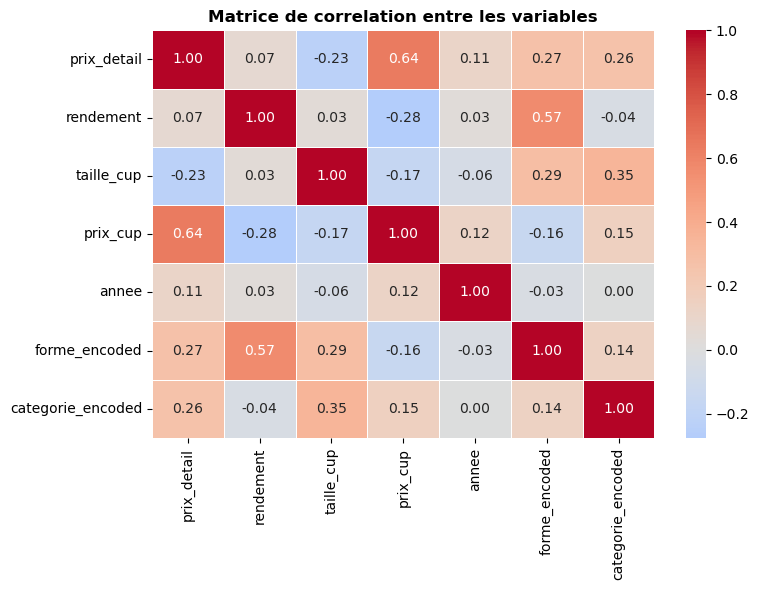

In [11]:
# Matrice de corrélation
# Montre les relations entre les variables numériques
# Plus la valeur est proche de 1 ou -1, plus la relation est forte
cols_corr = ['prix_detail', 'rendement', 'taille_cup', 'prix_cup',
             'annee', 'forme_encoded', 'categorie_encoded']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de correlation entre les variables', fontweight='bold')
plt.tight_layout()
plt.show()

Features les plus utiles pour prédire prix_cup :
prix_detail à 0.64 — c'est la corrélation la plus forte. Un produit cher au kilo en rayon est souvent cher par portion. Ce sera la feature la plus importante du modèle.

rendement à -0.28 — corrélation négative. Un rendement élevé (peu de déchets à la préparation) correspond à des produits moins chers par cup —  on perd moins de matière.

taille_cup à -0.17 — légère corrélation négative. Les grandes portions coûtent un peu moins cher par cup.

Features peu utiles :
annee à 0.12 — presque zéro. L'inflation entre 2013 et 2023 est très faible dans ce dataset — les prix n'ont pas beaucoup bougé en valeur relative.
categorie_encoded à 0.15 — les fruits et légumes ont des prix similaires en moyenne.
forme_encoded à -0.16 — la forme encode mal la relation car Fresh=0 et Dried=4 mais Dried est souvent plus cher que Fresh.


Conclusion pour le ML : les 3 features vraiment utiles sont prix_detail, rendement et taille_cup. Les autres apporteront peu au modèle mais on les garde quand même.

## 6. Export

On sauvegarde le dataset nettoyé avec toutes les modifications.
Ce fichier `fruits_legumes.csv` sera utilisé dans les notebooks suivants.

In [12]:
# Sauvegarde du dataset final
# index=False : on ne sauvegarde pas les numéros de lignes
# sep=';'     : séparateur point-virgule
# encoding    : UTF-8 pour les caractères spéciaux
df.to_csv('../DATA/CLEAN/fruits_legumes.csv', index=False, sep=';', encoding='utf-8')

print('Export OK')
print(f'Fichier  : fruits_legumes.csv')
print(f'Lignes   : {df.shape[0]}')
print(f'Colonnes : {df.shape[1]}')
print(f'Annees   : {sorted(df["annee"].unique())}')
df.head(3)

Export OK
Fichier  : fruits_legumes.csv
Lignes   : 704
Colonnes : 10
Annees   : [2013, 2016, 2020, 2022, 2023]


,produit,forme,prix_detail,rendement,taille_cup,prix_cup,categorie,annee,forme_encoded,categorie_encoded
0,Watermelon,Fresh,0.3334,0.520000,0.330693,0.2120,fruit,2013,0,1
1,Turnip greens,Frozen,1.4730,0.776027,0.352740,0.6696,legume,2013,2,0
2,Turnip greens,Fresh,2.4717,0.750000,0.319670,1.0535,legume,2013,0,0


## Bilan ETL

**Ce notebook :**
- Charge le dataset compilé USDA ERS (5 années, 704 lignes, 132 produits)
- Vérifie la qualité (0 valeurs manquantes, 0 doublons)
- Nettoie les colonnes texte et encode les variables pour le ML
- Identifie `prix_cup` comme variable cible continue pour la régression
- Produit 5 visualisations pour explorer les données
- Exporte `fruits_legumes.csv`

**Limites identifiées :**
- Les années ne se suivent pas (2013, 2016, 2020, 2022, 2023)
- Prix moyens nationaux — pas de données géographiques
- Les outliers (mangues séchées, cerises) sont des vraies valeurs conservées

**Prochaine étape :** Enrichissement avec NASS, Open-Meteo, EIA, World Bank, BLS